# Installing and importing necessary libraries

In [1]:
%pip install git+https://github.com/KindXiaoming/pykan.git

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-3_c03qdl
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-3_c03qdl
  Resolved https://github.com/KindXiaoming/pykan.git to commit f6ac7e25ed4cd99aba2b9c883d1cf25f959f6ac4
  Preparing metadata (setup.py) ... done
  Created wheel for pykan: filename=pykan-0.0.5-py3-none-any.whl size=44470 sha256=3b8c14b8bf1f183b452ef4c5b1ff2338b2693c542def7307de764e0bc4227c18
  Stored in directory: /tmp/pip-ephem-wheel-cache-j46jbzx9/wheels/47/ca/5a/98124e020f3119f51c17f78738c621c140b7aa803b0feda76e
Successfully built pykan


In [2]:
from kan import KAN, LBFGS

In [3]:
import torch
from torch import autograd
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import matplotlib.pyplot as plt


import torch.nn as nn

import numpy as np
import pandas as pd

import os

from torch.autograd import Variable

import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from scipy.interpolate import griddata
from collections import OrderedDict
import scipy
from scipy.optimize import curve_fit

import zipfile, io, os, sys

import requests, sys
import urllib.parse
from urllib.parse import urlencode
import gc
from google.colab import files as filescolab

In [4]:
%pip install wandb -qU

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 23.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.1/296.1 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 5.3 MB/s eta 0:00:00


In [5]:
import wandb

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [7]:
# functions for loading data from Yandex.Disk

def getZipDirs(zip_f, isRootDirOnly = False, addPath = True):
  dirs = []
  for f in zip_f.namelist():
    zinfo = zip_f.getinfo(f)
    if zinfo.is_dir():
      if isRootDirOnly:     # Only root directories:
        # This is will work in any OS because the zip format specifies a forward slash.
        r_dir = f.split('/')
        r_dir = r_dir[0]
        if r_dir not in dirs:
          dirs.append(r_dir)
      else: # All directories:
          dirs.append(f)
  if addPath:
    for dir in dirs:
      sys.path.append(os.path.abspath(dir + "/"))
  return dirs

def loadTextFromYandexDisk(url: str, isZip = False):
  base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
  final_url = base_url + urlencode(dict(public_key=url))
  response = requests.get(final_url)
  download_url = response.json()['href']
  download_response = requests.get(download_url)

  if isZip:
    zip = zipfile.ZipFile(io.BytesIO(download_response.content))
    dirs = getZipDirs(zip, True)
    zip.extractall()
  else:
    download_response.encoding = download_response.apparent_encoding
    return download_response.text

# Properties of air

In [8]:
def eta_mol(T): #K-> Pa*s
    return -8.38278e-7+8.35717342e-8*T-7.69429583e-11*(T**2)+4.6437266E-14*(T**3)-1.06585607e-17*(T**4)

def Cp_det(T): #K
    return 1047.63657-0.372589265*T+9.45304214E-4*(T**2)-6.02409443E-7*(T**3)+1.2858961E-10*(T**4)

def rho_def(T, pA=1e5): #K
    R_const = 8.3145
    M_mol = 0.02897
    return pA*M_mol/R_const/T

def lam_mol(T): #K
    return -0.00227583562+1.15480022E-4*T-7.90252856E-8*(T**2)+4.11702505E-11*(T**3)-7.43864331E-15*(T**4)

# Data
Loading data from simulation (for comparison with predicted fields) and experimental data. There are for different series of data with various inlet temperature: 200, 300, 400, 500 degrees Celsius. In this case we will work with the first series (200 degrees).

## 1. 200 degrees Celsius

In [9]:
#Simulation: weakly compressible flow, not modified Spalart–Allmaras model
#series: 200 degrees Celsius inlet

ref = 'https://disk.yandex.ru/d/_pGyfLtvnMJojA'
loadTextFromYandexDisk(ref, isZip=True)

In [10]:
#Simulation: weakly compressible flow, K-EPS model
#series: 200 degrees Celsius inlet

ref = 'https://disk.yandex.ru/d/Y7aoXETUP3H6Ww'
loadTextFromYandexDisk(ref, isZip=True)

In [11]:
# Filtered experimental temperature field with denoising autoencoder
#series: 200 degrees Celsius inlet

ref = 'https://disk.yandex.ru/d/nIv_2_pOXPUqJQ'
loadTextFromYandexDisk(ref, isZip=True)

In [12]:
# experimental raw data BOS
#series: 200 degrees Celsius inlet

ref_exp = 'https://disk.yandex.ru/d/-VPCLpFHiswgQA'
loadTextFromYandexDisk(ref_exp, isZip=True)

## 2. 300 degrees Celsius

In [13]:
#Simulation: weakly compressible flow, K-EPS model
#series: 300 degrees Celsius inlet

ref='https://disk.yandex.ru/d/5WjRyiEJX8DSwg'
loadTextFromYandexDisk(ref, isZip=True)

In [14]:
# experimental raw data BOS
# series: 300 degrees Celsius inlet

ref_exp = 'https://disk.yandex.ru/d/SIUPmg592fqkhA'
loadTextFromYandexDisk(ref_exp, isZip=True)

## 3. 400 degrees Celsius

In [15]:
#Simulation: weakly compressible flow, K-EPS model
#series: 400 degrees Celsius inlet

ref_exp='https://disk.yandex.ru/d/_hp1QAAWk_oq1w' #2_400_grad
loadTextFromYandexDisk(ref_exp, isZip=True)

In [16]:
# experimental raw data BOS
# series: 400 degrees Celsius inlet

ref='https://disk.yandex.ru/d/_hp1QAAWk_oq1w'
loadTextFromYandexDisk(ref, isZip=True)

## 4. 500 degrees Celsius

In [17]:
#Simulation: weakly compressible flow, K-EPS model
#series: 500 degrees Celsius inlet

ref_exp='https://disk.yandex.ru/d/ytorZyMTfgF09w'
loadTextFromYandexDisk(ref_exp, isZip=True)

In [18]:
# experimental raw data BOS,
#series: 500 degrees Celsius inlet

ref_exp='https://disk.yandex.ru/d/ytorZyMTfgF09w'
loadTextFromYandexDisk(ref_exp, isZip=True)

# Task parameters (constants, standardization values)


In [19]:
# constants
p0 = 1e5 #Pa, external pressure
T0 = 22 #gradC, external temperature, gradC
mu0 = 200 # value for normalization of dynamic viscosity
lam0 = 150 # value for normalization of thermal conductivity

v0 = 9 # m/s,  value for normalization of axial velocity VZ
a0 = 0.3  # 1/s,  value for normalization of a (Vr=a*r)
Pr_t = 0.9 #The turbulent Prandtl number
d0 = 0.011 #m, nozzle diameter
Tnorm = 200 # K, value for normalization of temperature
rmin, rmax = 0, 0.066199 # m, shape of experimental data grid
zmin, zmax = 0, 0.196749 # m, shape of experimental data grid

vr_0 = 0.05
#vr_0 = 1
p_0 = 0.03

l = min(rmax, zmax)
z_0 = round(zmax/l)

N, M = 30, 60 # computational grid

Tref = T0 + 273.15

mu_mol = eta_mol(Tref) # Pa*s
lambda_mol = lam_mol(Tref) # W / m / gradC
Cp = Cp_det(Tref) #J / (kg * gradC)
rho0 = rho_def(Tref, pA=p0) # const rho

pres0 = rho_def(Tref, pA=p0) * (v0**2)

Re0 = rho0 * v0 * l / mu_mol
Pe0 = rho0 * Cp * v0 * l / lambda_mol

In [20]:
# function for reading and preparing experimental data

def read_data(path, r, z):
    df = pd.read_csv(path, names = ['r', 'z', 'f'], sep='\s+')

    try:
        df.iloc[0, :].str.isalpha().sum()
        df = pd.read_csv(path)
        df.columns = ['r', 'z', 'f']
    except AttributeError:
        pass

    if df.z.isnull().any():
        df = pd.read_csv(path, names = ['r', 'z', 'f'])
    if df.z.max() > 10:
        df.z *= 1e-2
        df.r *= 1e-2
    print(f'zmin_exp={df.z.min()}, zmax_exp={df.z.max()}')
    print(f'rmin_exp={df.r.min()}, rmax_exp={df.r.max()}')
    f = griddata((df.r, df.z), df['f'], (r, z))
    nani = np.argwhere(np.isnan(f))
    for i in nani:
        if i[0]-1 > 0 and ~np.isnan(f[i[0]-1, i[1]]):
            f[i[0], i[1]] = f[i[0]-1, i[1]]
        else:
            mask = np.isnan(f)
            f[mask] = np.mean(f[~mask])
    if 'T.txt' in path or '_temperature.csv' in path:
        if np.min(f) > 294:
            f -= (273.15 + 22)
        elif np.min(f) > 273:
            f -= 273.15
        else:
            f -= np.min(f)
    f[0]=f[1]

    return f

In [21]:
class ExpData(Dataset):
    def __init__(
            self,
            pathfile = '/content/200_11_9/',
            pathexpfile = None,
            wc=0,
            M=50,
            N=50
            ):
        self.M = M
        self.N = N
        self.wc = wc
        simdataU = pd.read_csv(pathfile+'Vr.txt', \
                          sep='\s+', header=None, names=['r', 'z', 'f'])
        simdataW = pd.read_csv(pathfile+'Vz.txt', \
                          sep='\s+', header=None, names=['r', 'z', 'f'])
        simdataP = pd.read_csv(pathfile+'P.txt', \
                          sep='\s+', header=None, names=['r', 'z', 'f'])
        simdataMut = pd.read_csv(pathfile+'muT.txt', \
                          sep='\s+', header=None, names=['r', 'z', 'f'])
        simdataT = pd.read_csv(pathfile+'T.txt', \
                    sep='\s+', header=None, names=['r', 'z', 'f'])

        self.rho0 = rho_def(T0 + 273.15)
        self.vr = self.interpolatedata(simdataU)
        self.vz = self.interpolatedata(simdataW)
        self.a = self.vr / self.r
        vz_0 = np.array(np.diff(self.vz[:,0])/np.diff(self.z[:,0]))
        vz_0[-1] = vz_0[-2]
        vz_0 = np.append(vz_0, vz_0[-1])
        self.a[:,0] = -0.5*vz_0

        pc = np.polyfit(self.z[3:13,0], self.a[3:13,0], deg=1)
        p = np.poly1d(pc)
        self.a[:3,0] =  p(self.z[:3,0])

        self.p = self.interpolatedata(simdataP)
        self.mut = self.interpolatedata(simdataMut)
        self.Tsim = self.interpolatedata(simdataT)
        if pathexpfile:
            Texpraw = read_data(pathexpfile, self.r, self.z)
            self.T = Texpraw.reshape(N, M)
        else:
            self.T = self.Tsim
        if wc:
            self.lambt = self.mut * eta_mol(self.T+Tref)*Cp/Pr_t/lambda_mol
        else:
            self.lambt = self.mut*Cp/Pr_t*mu_mol/lambda_mol

    def interpolatedata(self, data):
        r = np.linspace(rmin,  rmax, num=self.M)
        z = np.linspace(zmin,  zmax, num=self.N)
        self.r1D = r
        self.z1D = z
        r, z = np.meshgrid(r, z)

        r, z = np.meshgrid(self.r1D, self.z1D)

        self.r = r
        self.z = z

        finterp = griddata((data.r, data.z), data.f, (r, z))
        finterp[-1, :] = finterp[-2, :]

        return finterp

    def normalization(self):

        self.r = self.r / l
        self.z = self.z / l / z_0

        self.r1D = self.r1D / l
        self.z1D = self.z1D / l


        self.vr = self.vr / v0 / vr_0
        self.vz = self.vz / v0
        self.T = self.T / Tnorm
        self.Tsim = self.Tsim / Tnorm
        pres0 = rho_def(T0 + 273.15) * (v0**2) # CONST
        self.p = self.p / pres0 / p_0
        if self.wc:
            self.mut = self.mut * eta_mol(self.T*Tnorm+Tref) / mu_mol / mu0
        else:
            self.mut = self.mut / mu0
        self.lambt = self.lambt / lam0

        self.a = self.a/(v0/l)/a0

    def __getitem__(self):
        pass

In [22]:
simFields = ExpData(pathfile='/content/4_weakly_compressible_K-EPS_gauss/',
                    pathexpfile='/content/0_200grad_temperature.csv',
                    wc=1, M=M, N=N)

<ipython-input-21-416ec737ef3f>:27: RuntimeWarning: invalid value encountered in divide
  self.a = self.vr / self.r


zmin_exp=0.0, zmax_exp=0.200094
rmin_exp=0.0, rmax_exp=0.069456


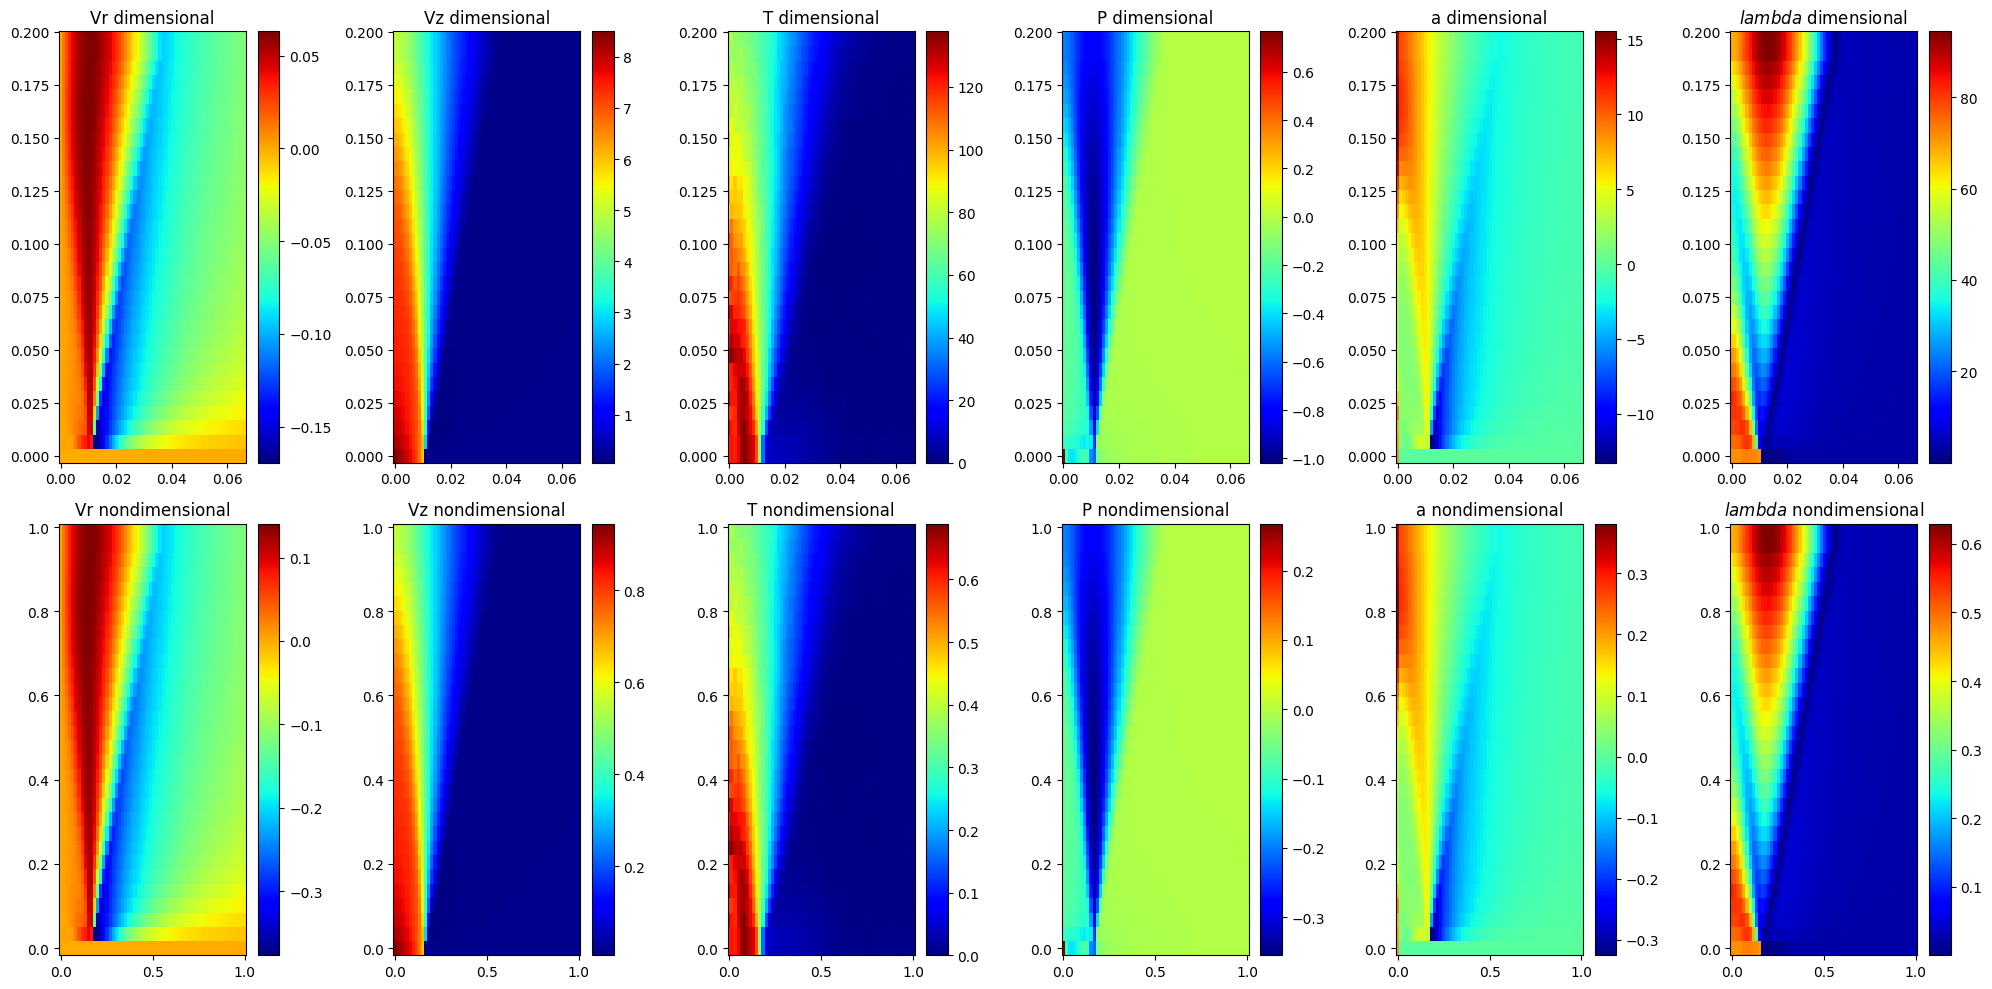

In [23]:
# Check and normilize all data

fig, ax = plt.subplots(2, 6, figsize=(20, 10))
titles = ['Vr', 'Vz', 'T', 'P', 'a', r'$\lambda$']

for i, field in enumerate((simFields.vr, simFields.vz,
                           simFields.T, simFields.p, simFields.a,
                           simFields.lambt)):
    im = ax[0, i].pcolor(simFields.r, simFields.z, field, cmap='jet')
    ax[0, i].set_title(titles[i]+' dimensional')
    plt.colorbar(im, ax=ax[0, i])

#normalization
simFields.normalization()

for i, field in enumerate((simFields.vr, simFields.vz,
                           simFields.T, simFields.p, simFields.a,
                           simFields.lambt)):
    im = ax[1, i].pcolor(simFields.r, simFields.z, field, cmap='jet')
    ax[1, i].set_title(titles[i]+' nondimensional')
    plt.colorbar(im, ax=ax[1, i])

plt.tight_layout()
plt.show()

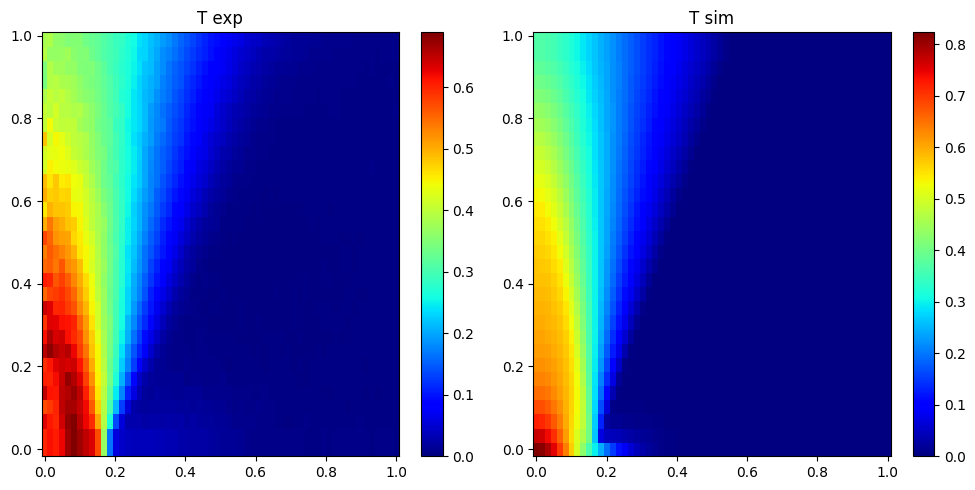

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

im = ax[0].pcolor(simFields.r, simFields.z, simFields.T, cmap='jet')
ax[0].set_title('T exp')
plt.colorbar(im, ax=ax[0])

im = ax[1].pcolor(simFields.r, simFields.z, simFields.Tsim, cmap='jet')
ax[1].set_title('T sim')
plt.colorbar(im, ax=ax[1])

plt.tight_layout()

plt.show()

In [25]:
print(f'Vr_max:{np.max(np.abs(simFields.vr))}')
print(f'Vz_max:{np.max(np.abs(simFields.vz))}')
print(f'T_max:{np.max(np.abs(simFields.T))}')
print(f'p_max:{np.max(np.abs(simFields.p))}')
print(f'muT_max:{np.max(np.abs(simFields.mut))}')
print(f'lambT_max:{np.max(np.abs(simFields.lambt))}')
print(f'a_max:{np.max(np.abs(simFields.a))}')

Vr_max:0.376716503789911
Vz_max:0.9444444444444444
T_max:0.6888441504317412
p_max:0.3548285623328473
muT_max:0.60046997725773
lambT_max:0.6292419250214404
a_max:0.3811313996025826


# Initial conditions, mask for equation residuals


In [27]:
# To calculate metrics data must in tensors

Ttarget = torch.from_numpy(simFields.T).flatten().to(device)
Utarget = torch.from_numpy(simFields.vr).flatten().to(device)
Atarget = torch.from_numpy(simFields.a).flatten().to(device)
Vtarget = torch.from_numpy(simFields.vz).flatten().to(device)
Ptarget = torch.from_numpy(simFields.p).flatten().to(device)
Mutarget = torch.from_numpy(simFields.mut).flatten().to(device)
lambtarget = torch.from_numpy(simFields.lambt).flatten().to(device)

In [36]:
def functanhmax(r, vmax=8.5, sigma=0.05):
    '''sigma - parameter for smooth shifting
       vmax - max inlet velocity
    '''
    return 0.5*vmax*(1-np.tanh((r-d0/l)/sigma))/v0

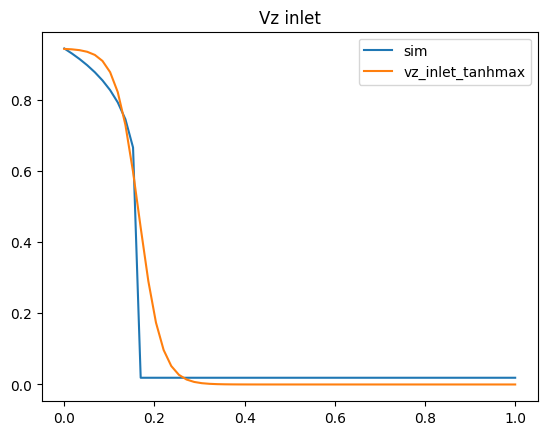

In [37]:
plt.plot(simFields.r[0,:], simFields.vz[0,:], label='sim')

th_vz_max = functanhmax(simFields.r[0,:])

plt.plot(simFields.r[0,:], th_vz_max, label='vz_inlet_tanhmax')
plt.title('Vz inlet')
plt.legend()
plt.show()

In [38]:
# lam_inlet = 10 - as in SA-model
def lambd_inlet(r, lam_inlet=10, lam_ext=3):
  f = np.ones_like(r) * lam_ext / lam0
  f[r*l <= d0] = lam_inlet / lam0
  return f

In [39]:
lambd_in = lambd_inlet(simFields.r[0,:])

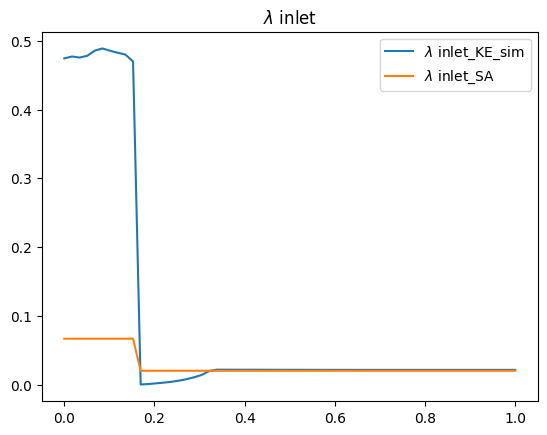

In [40]:
plt.plot(simFields.r[0,:], simFields.lambt[0,:], label=r'$\lambda$ inlet_KE_sim')
plt.plot(simFields.r[0,:], lambd_in, label=r'$\lambda$ inlet_SA')
plt.legend()
plt.title(r'$\lambda$ inlet')
plt.show()

In [41]:
lambd_in = torch.from_numpy(lambd_in).to(device)
th_vz_max = torch.from_numpy(th_vz_max).to(device)

In [42]:
maskRZT = torch.ones(N, M)
maskRZT[0,:] = 0
maskRZT[:,0] = 0
maskRZTvis = maskRZT
maskRZT = maskRZT.flatten().to(device)

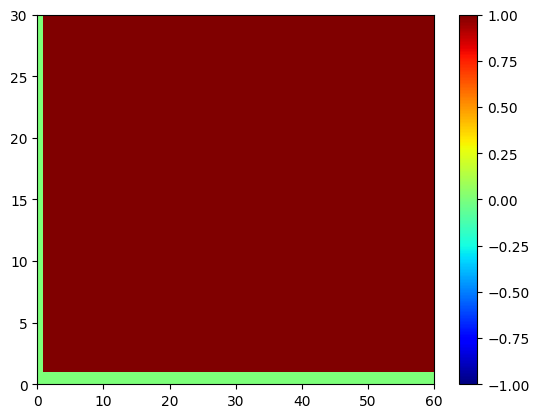

In [43]:
plt.pcolor(maskRZTvis.detach().cpu(), cmap='jet', vmin=-1, vmax=1)
plt.colorbar()
plt.show()

In [44]:
class Metrics_ac():
    def __init__(self):

        self.NRMSE_mean = lambda x, y: \
                    torch.sqrt(torch.mean(torch.pow(x-y, 2)))/ \
                    torch.abs(torch.mean(y))
        self.NRMSE_max = lambda x, y: \
                    torch.sqrt(torch.mean(torch.pow(x-y, 2)))/ \
                    torch.abs(torch.max(y))

    def calculate(self, pred, target):
        mean_m= self.NRMSE_mean(pred.float(), target.float())
        max_m = self.NRMSE_max(pred.float(), target.float())
        return mean_m, max_m

# Model (PINN or KAN)

In [45]:
from typing import OrderedDict

class PINN_2d(nn.Module):
    def __init__(self,
                input_size = 2,
                hidden_size = 30*5,
                output_size = 5,
                 ):
        super().__init__()

        self.layers_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), #1
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), #2
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), # 3
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), #4
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), # 5
            nn.Tanh(),
            nn.Linear(hidden_size, output_size),
            nn.Tanh(),
        )

    def forward(self, x):
        y = self.layers_stack(x)
        return y

In [55]:
model = PINN_2d().to(device)
#model = KAN(width=[2,3,3, 5], grid=20, k=9, grid_eps=1.0,
#            noise_scale_base=0.25, device=device)

In [ ]:
#gc.collect()
#torch.cuda.empty_cache()

In [47]:
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [56]:
wandb.init(
        settings=wandb.Settings(start_method="thread"),
        project="PINN_exp_200grad",
        config={
            "comment": 'exp'
            })

T_max,█▇▆▆▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▂
T_mean,█▇▆▆▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▂
VZ_max,██▇▆██▆▅▅▅▅▄▄▄▅▄▄▄▃▃▃▃▃▃▃▃▃▃▄▃▃▃▂▂▁▁▁▁▁▁
VZ_mean,██▇▆██▆▅▅▅▅▄▄▄▅▄▄▄▃▃▃▃▃▃▃▃▃▃▄▃▃▃▂▂▁▁▁▁▁▁
a_max,█▃▃▃▃▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▂
a_mean,█▃▃▃▃▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▂
axis_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁
continuity,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dataAloss,█▃▂▂▃▂▂▂▂▂▂▂▂▂▃▂▂▂▂▂▂▂▃▂▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▂
dataMuloss,▇▇▅▃▁▁▃▃▁▁▂▃▅▄▇▃▃█▄▄▃▃▄▃▃▃▃▃▄▃▂▂▂▃▃▃▃▃▄▃
dataPloss,█▇▇▇▆▆▆▆▅▅▄▃▃▅▁▂▂▂▂▅▄▂▂▂▂▄██▆▆▆▅▇▇▄▅▅▆▅▅


# Training

In [51]:
eps = 1e-6 # add in member which contains 1/r

R, Z = torch.meshgrid(torch.from_numpy(simFields.r[0,:]),
                      torch.from_numpy(simFields.z[:,0]), indexing='xy')
width = simFields.r.max()
height = simFields.z.max()

coordinates = torch.stack([R.flatten(), Z.flatten()], dim=1).to(device)
coordinates.requires_grad = True  # Ensure coordinates require grad

writer = SummaryWriter()
train_acc = Metrics_ac()

In [57]:
def navier_stokes_residuals(coords, inds):

    coords = coords.clone().detach().requires_grad_(True)
    y_pred = model(coords.float())
    r = coords[:, 0]

    a, v, T, p, lamT = y_pred[:, 0], y_pred[:, 1], y_pred[:, 2], \
                      y_pred[:, 3], y_pred[:, 4]

    acc_metrics = dict()

    mean_m, max_m = train_acc.calculate(a, Atarget[inds])

    acc_metrics['a_mean'], acc_metrics['a_max'] = mean_m, max_m
    mean_m, max_m = train_acc.calculate(v, Vtarget[inds])
    acc_metrics['VZ_mean'], acc_metrics['VZ_max'] = mean_m, max_m
    mean_m, max_m = train_acc.calculate(T, Ttarget[inds])
    acc_metrics['T_mean'], acc_metrics['T_max'] = mean_m, max_m
    mean_m, max_m = train_acc.calculate(p, Ptarget[inds])
    acc_metrics['p_mean'], acc_metrics['p_max'] = mean_m, max_m
    mean_m, max_m = train_acc.calculate(lamT, lambtarget[inds])
    acc_metrics['lambd_mean'], acc_metrics['lambd_max'] = mean_m, max_m

    a_r = torch.autograd.grad(a, coords, torch.ones_like(a), \
                              create_graph=True, \
                            retain_graph=True)[0][:, 0]
    vz_r = torch.autograd.grad(v, coords, torch.ones_like(v), \
                               create_graph=True, \
                            retain_graph=True)[0][:, 0]
    vz_z = torch.autograd.grad(v, coords, torch.ones_like(v), \
                               create_graph=True, \
                            retain_graph=True)[0][:, 1]/ z_0
    p_r = torch.autograd.grad(p, coords, torch.ones_like(p), \
                              create_graph=True, \
                            retain_graph=True)[0][:, 0]
    lamT_r = torch.autograd.grad(lamT, coords, torch.ones_like(lamT), \
                                 create_graph=True, \
                            retain_graph=True)[0][:, 0]

    def cont_eq(a, v, T, p, lamT):
      a = a * a0
      r = coords[:, 0]

      rho = (T0 + 273.15) / (T * Tnorm + T0 + 273.15) # in equation
      rho_r = torch.autograd.grad(rho, coords, torch.ones_like(rho), \
                                  create_graph=True, \
                              retain_graph=True)[0][:, 0]
      a_r = torch.autograd.grad(a, coords, torch.ones_like(a), \
                                create_graph=True, \
                              retain_graph=True)[0][:, 0]
      rho_z = torch.autograd.grad(rho, coords, torch.ones_like(rho), \
                                  create_graph=True, \
                              retain_graph=True)[0][:, 1]/ z_0
      v_z = torch.autograd.grad(v, coords, torch.ones_like(rho), \
                                create_graph=True, \
                              retain_graph=True)[0][:, 1]/ z_0

      f1 = a*r*rho_r+rho*r*a_r+2*rho*a+v*rho_z+rho*v_z
      return f1

    def r_momentum_eq(a, v, T, p, lamT):
      #eps = 1e-6
      r = coords[:, 0] + eps
      mu = Pr_t/Cp*lamT*lam0*lambda_mol/mu_mol + 1
      a = a * a0
      p = p * p_0

      rho = (T0 + 273.15) / (T * Tnorm + T0 + 273.15) # in equation

      #derivatives
      a_r = torch.autograd.grad(a, coords, torch.ones_like(a), \
                                create_graph=True, \
                        retain_graph=True)[0][:, 0]
      a_z = torch.autograd.grad(a, coords, torch.ones_like(a), \
                                create_graph=True, \
                        retain_graph=True)[0][:, 1]/ z_0
      vz_r = torch.autograd.grad(v, coords, torch.ones_like(v), \
                                 create_graph=True, \
                              retain_graph=True)[0][:, 0]
      vz_z = torch.autograd.grad(v, coords, torch.ones_like(v), \
                                 create_graph=True, \
                              retain_graph=True)[0][:, 1]/ z_0
      vr_r = r * a_r + a
      vr_z = r * a_z

      vz_r = torch.autograd.grad(v, coords, torch.ones_like(rho), \
                                 create_graph=True, \
                              retain_graph=True)[0][:, 0]
      vz_z = torch.autograd.grad(v, coords, torch.ones_like(rho), \
                                 create_graph=True, \
                              retain_graph=True)[0][:, 1]/ z_0
      p_r = torch.autograd.grad(p, coords, torch.ones_like(rho), \
                                create_graph=True, \
                              retain_graph=True)[0][:, 0]

      # div V = 1/r*d_dr(r*VR)+d_dz(VZ)
      div_v =  r*a_r+2*a+vz_z

      # NS equation, r-projection
      # rho * (u * d_u/d_r + w * d_u/d_z)
      n1 = rho * (a*r*(r*a_r+a)+v*r*a_z)
      #-d_p/d_r
      n2 =  p_r
      # 1/Re0 * (d_(mu_*(-2/3 * div_v + 2*u_r))/d_r)


      n3 = 1/Re0 * torch.autograd.grad(mu*(-2/3*div_v + 2*vr_r),\
                          coords, torch.ones_like(rho), create_graph=True, \
                              retain_graph=True)[0][:, 0]
      # 1/Re0 * d_(mu * (u_z + w_r))/d_z
      n4 = 1/Re0 *torch.autograd.grad(mu*1*(vr_z + vz_r),\
                          coords, torch.ones_like(rho), create_graph=True, \
                              retain_graph=True)[0][:, 1]/ z_0
      # 2/Re0 * mu/r * (u_r-u/r)
      n5 = 2/Re0 * mu / r * (vr_r - a)

      f2 = n1 - (n2 + n3 + n4 + n5)
      return f2

    def z_momentum_eq(a, v, T, p, lamT):
      eps = 1e-6
      r = coords[:, 0]

      mu = Pr_t/Cp*lamT*lam0*lambda_mol/mu_mol + 1
      a = a * a0
      p = p * p_0
      u = a * r

      #rho = torch.ones_like(T) # in equation
      rho = (T0 + 273.15) / (T * Tnorm + T0 + 273.15) # in equation

      #derivatives
      a_r = torch.autograd.grad(a, coords, torch.ones_like(a), \
                                create_graph=True, \
                        retain_graph=True)[0][:, 0]
      a_z = torch.autograd.grad(a, coords, torch.ones_like(a), \
                                create_graph=True, \
                        retain_graph=True)[0][:, 1]/ z_0
      vr_r = r * a_r + a
      vr_z = r * a_z
      vz_r = torch.autograd.grad(v, coords, torch.ones_like(rho),\
                                 create_graph=True, \
                        retain_graph=True)[0][:, 0]
      vz_z = torch.autograd.grad(v, coords, torch.ones_like(rho), \
                                 create_graph=True, \
                              retain_graph=True)[0][:, 1]/ z_0

      p_z = torch.autograd.grad(p, coords, torch.ones_like(rho), \
                                create_graph=True, \
                              retain_graph=True)[0][:, 1]/ z_0

      # div V = 1/r*d_dr(r*VR)+d_dz(VZ)
      div_v =  r*a_r+2*a+vz_z

      # NS equation, z-projection
      # rho * (u * d_w/d_r + w * d_w/d_z)
      n1 = rho * (u * vz_r + v * vz_z)
      #-d_p/d_z
      n2 =  p_z
      # 1/Re0 * (d_(mu_*(-2/3 * div_v + 2*w_z))/d_z)
      n3 = 1/Re0 * 1*torch.autograd.grad(mu*(-2/3*div_v + 2*vz_z),\
                          coords, torch.ones_like(rho), create_graph=True, \
                              retain_graph=True)[0][:, 1]/ z_0
      # 1/Re0 * d_(mu * (w_r + u_z))/d_r
      n4 = 1/Re0 * 1*torch.autograd.grad(mu*(vz_r + vr_z),\
                          coords, torch.ones_like(rho), create_graph=True, \
                              retain_graph=True)[0][:, 0]
      # 1/Re0 * mu / r * (u_z+w_r)
      n5 = 1/Re0 * mu * (a_z + vz_r /(eps+r))

      f3 = n1 - (n2 + n3 + n4 + n5)
      return f3

    def energy_eq(a, v, T, p, lamT):
      eps = 1e-6
      r = coords[:, 0]
      lamT = lamT * lam0
      a = a * a0
      p = p * p_0
      u = a * r

      #rho = torch.ones_like(T) # in equation
      rho = (T0 + 273.15) / (T * Tnorm + T0 + 273.15) # in equation

      #derivatives
      T_r = torch.autograd.grad(T, coords, torch.ones_like(rho), \
                                create_graph=True, \
                              retain_graph=True)[0][:, 0]
      T_z = torch.autograd.grad(T, coords, torch.ones_like(rho), \
                                create_graph=True, \
                              retain_graph=True)[0][:, 1]/ z_0

      #energy equation
      #rho*(u*d_T/d_r + w*d_T/d_z)
      n1 = rho * (u * T_r + v * T_z)
      #1/Pe0 * 1 / r * d_(lambda_*r*T_r)/dr
      n2 = 1/Pe0 * 1 / (eps+r)  * torch.autograd.grad(lamT*r*T_r, \
                              coords, torch.ones_like(rho), create_graph=True, \
                              retain_graph=True)[0][:, 0]
      #1/Pe0 * d_(lambda_*T_z)/dz
      n3 = 1/Pe0 *torch.autograd.grad(lamT*T_z, coords, torch.ones_like(rho), \
                                      create_graph=True, \
                              retain_graph=True)[0][:, 1]/ z_0
      f4 = n1 - (n2 + n3)
      return f4

    continuity = cont_eq(a, v, T, p, lamT)
    r_momentum = r_momentum_eq(a, v, T, p, lamT)
    z_momentum = z_momentum_eq(a, v, T, p, lamT)
    energy = energy_eq(a, v, T, p, lamT)

    dataTloss = torch.mean((Ttarget[inds] - T)**2)
    dataAloss = torch.mean((Atarget[inds] - a)**2)
    dataVloss = torch.mean((Vtarget[inds] - v)**2)
    dataPloss = torch.mean((Ptarget[inds] - p)**2)
    dataMuloss = torch.mean((lamT - lambtarget[inds])**2)

    free_mask = (coordinates[:, 0] == width)
    axis_mask = (coordinates[:, 0] == 0)
    outlet_mask = (coordinates[:, 1] == height)
    inlet_mask = (coordinates[:, 1] == 0)

    free_coords = coordinates[free_mask]
    inlet_coords = coordinates[inlet_mask]
    outlet_coords = coordinates[outlet_mask]
    axis_coords = coordinates[axis_mask]

    inlet_out = model(inlet_coords.float())
    outlet_out = model(outlet_coords.float())
    free_out = model(free_coords.float())
    axis_out = model(axis_coords.float())

    vz_r_axis = torch.autograd.grad(axis_out[:,1],\
                          axis_coords, torch.ones_like(axis_out[:,0]), \
                                    create_graph=True, \
                              retain_graph=True)[0][:, 0]
    vz_z_axis = torch.autograd.grad(axis_out[:,1],\
                        axis_coords, torch.ones_like(axis_out[:,0]), \
                                    create_graph=True, \
                            retain_graph=True)[0][:, 1]
    p_r_axis = torch.autograd.grad(axis_out[:,3],\
                          axis_coords, torch.ones_like(axis_out[:,0]), \
                                   create_graph=True, \
                              retain_graph=True)[0][:, 0]
    lam_r_axis = torch.autograd.grad(axis_out[:,4],\
                      axis_coords, torch.ones_like(axis_out[:,0]), \
                                     create_graph=True, \
                          retain_graph=True)[0][:, 0]
    rho_axis = (T0 + 273.15) / (axis_out[:,1]*Tnorm + T0 + 273.15) # in equation

    rho_axis_z = torch.autograd.grad(rho_axis, axis_coords, \
                                     torch.ones_like(rho_axis), \
                                     create_graph=True, \
                                     retain_graph=True)[0][:, 1]/ z_0

    axis_a_cond = 2*axis_out[:, 0]*rho_axis + rho_axis_z*axis_out[:, 1] + \
                  rho_axis*vz_z_axis # dVr/dr=0 on axis

    vz_z_out = torch.autograd.grad(outlet_out[:,1],\
                  outlet_coords, torch.ones_like(outlet_out[:,1]), \
                                   create_graph=True, \
                      retain_graph=True)[0][:, 1]/ z_0
    a_z_out = torch.autograd.grad(outlet_out[:,0],\
              outlet_coords, torch.ones_like(outlet_out[:,1]), \
                                  create_graph=True, \
                  retain_graph=True)[0][:, 1]/ z_0
    lam_z_out = torch.autograd.grad(outlet_out[:,4],\
          outlet_coords, torch.ones_like(outlet_out[:,1]), create_graph=True, \
              retain_graph=True)[0][:, 1]/ z_0
    p_z_out = torch.autograd.grad(outlet_out[:,3],\
          outlet_coords, torch.ones_like(outlet_out[:,1]), create_graph=True, \
              retain_graph=True)[0][:, 1]/ z_0


    inlet_loss = torch.mean((inlet_out[:,0]) ** 2) +\
                 torch.mean((inlet_out[:,1] - th_vz_max) ** 2)+\
                 torch.mean((inlet_out[:,4] - lambd_in) ** 2)

    free_loss =  torch.mean((free_out[:, 3]) ** 2)

    axis_loss = torch.mean(axis_a_cond**2)

    outlet_loss = torch.mean(p_z_out**2)


    continuity =continuity*maskRZT[inds]
    r_momentum = r_momentum*maskRZT[inds]
    z_momentum = z_momentum*maskRZT[inds]
    energy = energy*maskRZT[inds]

    L_cont = torch.mean(continuity**2)
    L_r = torch.mean(r_momentum**2)
    L_z = torch.mean(z_momentum**2)
    L_energy = torch.mean(energy**2)

    test_vals=np.array([dataTloss.item(),
               inlet_loss.item(),
               free_loss.item(),
               outlet_loss.item(),
               axis_loss.item(),
               L_cont.item(),
               L_r.item(),
               L_z.item(),
               L_energy.item()])

    total_loss = 100*(1e1*dataTloss + inlet_loss +free_loss)+\
                 +0.1*axis_loss+\
                 1e2*(L_energy + 1e1*L_r + L_z + 1e3*L_cont)

    metrics = {
        'continuity': L_cont,
        'r_momentum_': L_r.detach(),
        'z_momentum_': L_z.detach(),
        'energy': L_energy,
        'dataTloss': dataTloss,
        'dataAloss': dataAloss,
        'dataVloss': dataVloss,
        'dataPloss': dataPloss,
        'dataMuloss': dataMuloss,
        'inlet_loss': inlet_loss,
        'free_loss': free_loss,
        'axis_loss': axis_loss,
        'total_loss': total_loss,
        'outlet_loss': outlet_loss
    }
    wandb.log(metrics)
    wandb.log(acc_metrics)

    return total_loss

In [58]:
def train():
    optimizer = LBFGS(model.parameters(), lr=1,
                      history_size=10,
                      line_search_fn="strong_wolfe",
                        tolerance_grad=1e-32,
                      tolerance_change=1e-32,
                      tolerance_ys=1e-32)
    steps = 100000
    pbar = tqdm(range(steps), desc='Training Progress')
    last_step_loss = None

    for step in pbar:
        inds=list(range(len(coordinates)))
        #all_loss  = navier_stokes_residuals(coordinates, inds)
        inds=list(range(len(coordinates)))
        coord_batch = coordinates

        def closure():
            optimizer.zero_grad()
            all_loss  = navier_stokes_residuals(coord_batch, inds)
            loss = all_loss
            loss.backward()
            return loss
        optimizer.step(closure)
        if step % 2 == 0:

            current_loss = closure().item()
            pbar.set_description("Step: %d | Loss: %.3f" %
                                 (step, current_loss))
            writer.add_scalar('Loss/train', current_loss, step)
            if last_step_loss and np.abs(last_step_loss - current_loss) < 1e-10:
                return current_loss
            else:
                last_step_loss = current_loss

train()

writer.close()

Step: 884 | Loss: 0.056:   1%|          | 884/100000 [46:27<86:48:44,  3.15s/it]


# Save weights

In [59]:
torch.save(model.state_dict(), 'model_weights_PINN_1exp.pth')
filescolab.download("model_weights_PINN_1exp.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# load weights


In [ ]:
#model.load_state_dict(torch.load('/content/model_weights_KAN_vr=ar_check_cont3 (10).pth',\
#                                 map_location=torch.device('cpu')))

# Predictions on a uniform grid

In [60]:
Nu, Mu=100,100

if 1:
  simFieldsForPred = ExpData(pathfile='/content/4_weakly_compressible_K-EPS_gauss/',
                    pathexpfile='/content/0_200grad_temperature.csv',
                    wc=1, M=Mu, N=Nu)
  simFieldsForPred.normalization()

<ipython-input-21-416ec737ef3f>:27: RuntimeWarning: invalid value encountered in divide
  self.a = self.vr / self.r


zmin_exp=0.0, zmax_exp=0.200094
rmin_exp=0.0, rmax_exp=0.069456


In [61]:
r_uniform = torch.linspace(0, rmax/l, Nu)
z_uniform = torch.linspace(0, zmax/l/z_0, Mu)
r_u, z_u = torch.meshgrid(r_uniform, z_uniform)

u_grid = torch.vstack([r_u.flatten(), z_u.flatten()]).T
u_grid.requires_grad = True
u_grid = u_grid.to(device)
out = model(u_grid).to(device)

a = out[:, 0].detach().cpu().numpy().reshape(Nu, Mu).T
vz = out[:, 1].detach().cpu().numpy().reshape(Nu, Mu).T
T = out[:, 2].detach().cpu().numpy().reshape(Nu, Mu).T
lambt = out[:, 4].detach().cpu().numpy().reshape(Nu, Mu).T
p = out[:, 3].detach().cpu().numpy().reshape(Nu, Mu).T

rout = u_grid[:,0].detach().cpu().numpy().reshape(Nu, Mu).T
zout = u_grid[:,1].detach().cpu().numpy().reshape(Nu, Mu).T

/usr/local/lib/python3.10/dist-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


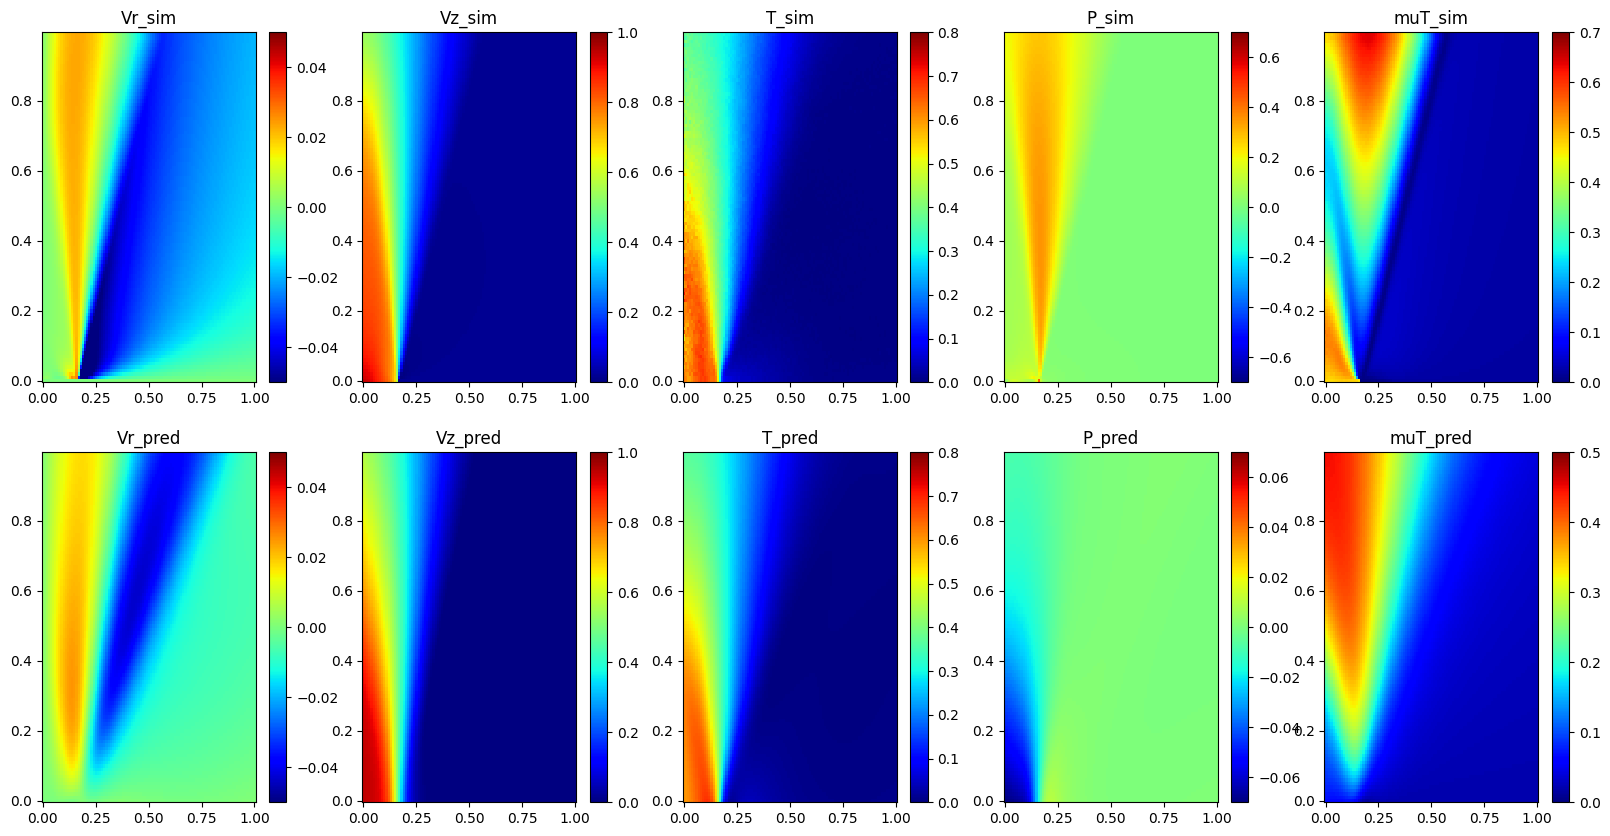

In [62]:
im = [simFieldsForPred.a, simFieldsForPred.vz,
      simFieldsForPred.T, -simFieldsForPred.p,
      simFieldsForPred.lambt]
out = [a, vz, T, p, lambt]

titles = ['Vr', 'Vz', 'T', 'P', 'muT']
ca_sim = [(-0.05, 0.05), (0, 1), (0,0.8), (-0.7, 0.7), (0, 0.7)]
ca_pred = [(-0.05, 0.05), (0, 1), (0,0.8), (-0.07, 0.07), (0, 0.5)]

fig, ax = plt.subplots(2, 5, figsize=(20, 10))

for i in range(5):
  if i == 0:
    im_tar = ax[0, i].pcolor(simFieldsForPred.r, simFieldsForPred.z,
                            simFieldsForPred.r*im[i],
                             cmap='jet', vmin=ca_sim[i][0], vmax=ca_sim[i][1])
  else:
    im_tar = ax[0, i].pcolor(simFieldsForPred.r, simFieldsForPred.z,
                            im[i], cmap='jet', vmin=ca_sim[i][0], vmax=ca_sim[i][1])
  plt.colorbar(im_tar, ax=ax[0, i])
  ax[0, i].set_title(titles[i]+'_sim')

  if i == 0:
    im_pred = ax[1, i].pcolor(rout, zout,out[i]*rout, cmap='jet', vmin=ca_pred[i][0], vmax=ca_pred[i][1])
  else:
    im_pred = ax[1, i].pcolor(rout, zout,out[i], cmap='jet', vmin=ca_pred[i][0], vmax=ca_pred[i][1])
  plt.colorbar(im_pred, ax=ax[1, i])
  ax[1, i].set_title(titles[i]+'_pred')

plt.show()

# Estimation of equation residuals

In [63]:
out = model(u_grid).to(device)

In [64]:
def cont_eq_test(a, v, T, p, lamT):
    lamT = lamT * lam0
    a = a * a0
    p = p * p_0
    r = u_grid[:, 0]

    rho = (T0 + 273.15) / (T * Tnorm + T0 + 273.15) # in equation
    rho_r = torch.autograd.grad(rho, u_grid, torch.ones_like(rho), create_graph=True, \
                            retain_graph=True)[0][:, 0]
    a_r = torch.autograd.grad(a, u_grid, torch.ones_like(a), create_graph=True, \
                            retain_graph=True)[0][:, 0]
    rho_z = torch.autograd.grad(rho, u_grid, torch.ones_like(rho), create_graph=True, \
                            retain_graph=True)[0][:, 1]/z_0
    v_z = torch.autograd.grad(v, u_grid, torch.ones_like(rho), create_graph=True, \
                            retain_graph=True)[0][:, 1]/z_0

    f1 = a*r*rho_r+rho*r*a_r+2*rho*a+v*rho_z+rho*v_z

    n1 = a*r*rho_r
    n2 = rho*r*a_r
    n3 = 2*rho*a
    n4 = v*rho_z
    n5 = rho*v_z

    return n1, n2, n3, n4, n5, f1

n1, n2, n3, n4, n5, f1 = cont_eq_test(out[:, 0], out[:, 1],out[:, 2],out[:, 3],out[:, 4])

In [65]:
torch.mean(f1**2)

tensor(7.1683e-08, device='cuda:0', grad_fn=<MeanBackward0>)

In [66]:
nf = [n1,n2,n3,n4,n5]
nr = []
for n in nf:
  nr.append(n.detach().cpu().numpy().reshape(Nu, Mu).T)

nr.append(nr[4] +nr[0] + nr[1] + nr[2] + nr[3])

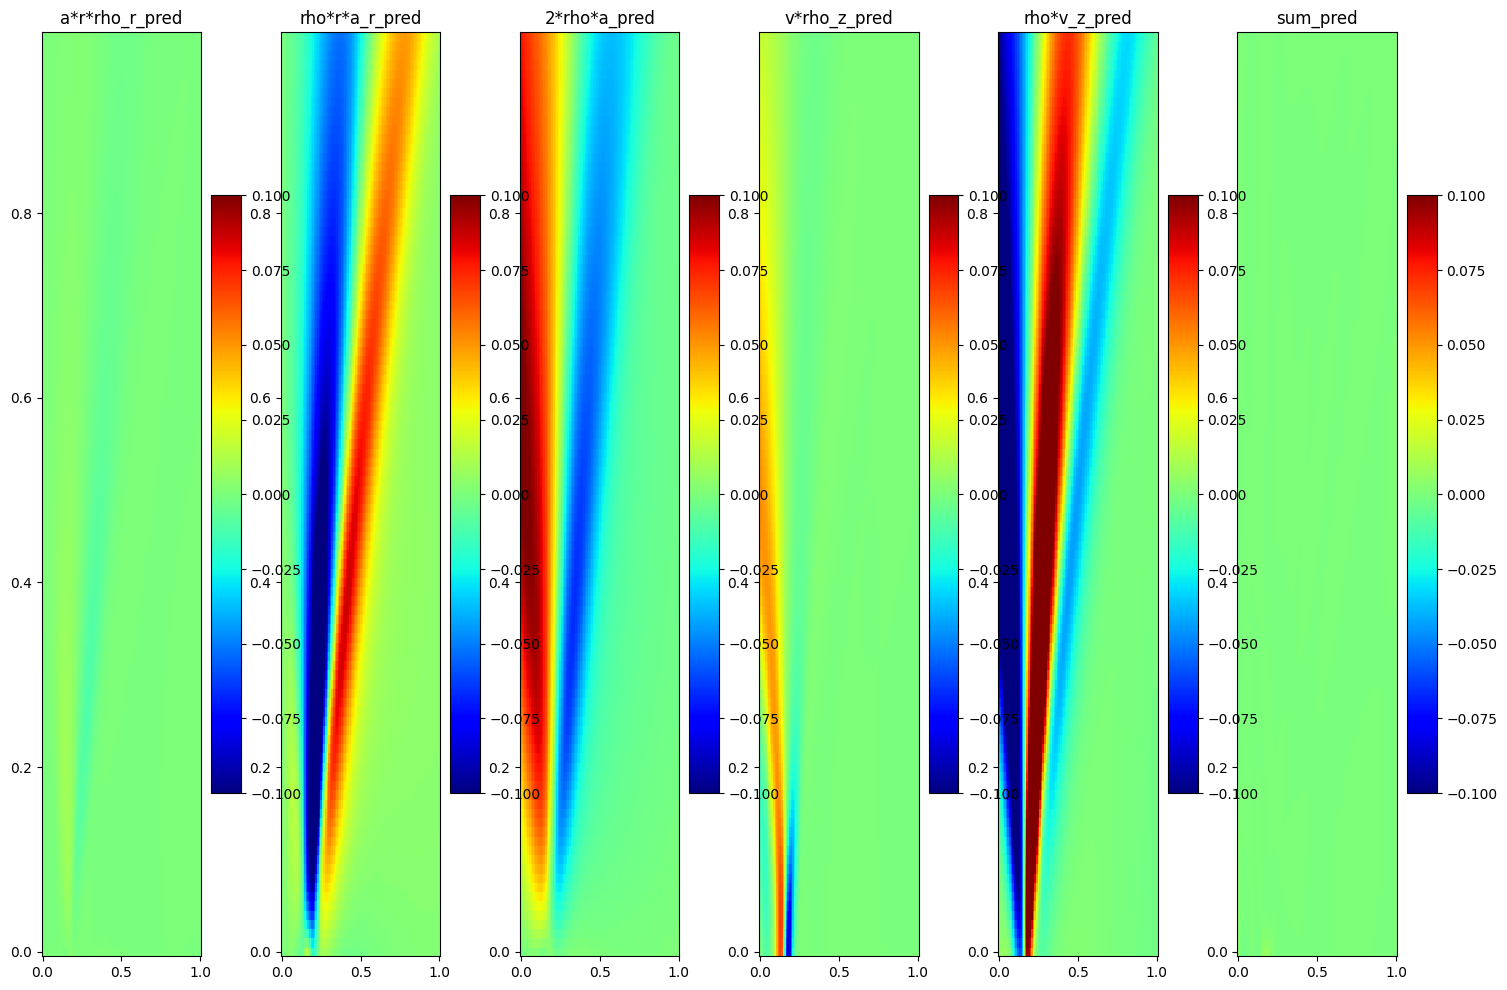

In [67]:
titles = ['a*r*rho_r', 'rho*r*a_r', '2*rho*a', 'v*rho_z', 'rho*v_z', 'sum']
#ca_sim = [(-0.1, 0.1), (-0.1, 0.1),
#          (-0.1, 0.1), (-0.1, 0.1), (-0.1, 0.1), (-0.1, 0.1)]
ca_sim = [(-0.1,0.1)]*6

fig, ax = plt.subplots(1, 6, figsize=(18, 12))

for i in range(6):
  im_tar = ax[i].pcolor(simFieldsForPred.r,
                        simFieldsForPred.z,
                        nr[i], cmap='jet', vmin=ca_sim[i][0], vmax=ca_sim[i][1])
  plt.colorbar(im_tar, ax=ax[i])
  ax[i].set_title(titles[i]+'_pred')

plt.show()

In [68]:
def r_momentum_eq(a, v, T, p, lamT):
    eps = 1e-7
    r = u_grid[:, 0] + eps

    mu = Pr_t/Cp*lamT*lam0*lambda_mol/mu_mol + 1
    a = a * a0
    p = p * p_0

    rho = (T0 + 273.15) / (T * Tnorm + T0 + 273.15) # in equation

    #derivatives
    a_r = torch.autograd.grad(a, u_grid, torch.ones_like(a), create_graph=True, \
                      retain_graph=True)[0][:, 0]
    a_z = torch.autograd.grad(a, u_grid, torch.ones_like(a), create_graph=True, \
                      retain_graph=True)[0][:, 1]/ z_0
    vz_r = torch.autograd.grad(v, u_grid, torch.ones_like(v), create_graph=True, \
                            retain_graph=True)[0][:, 0]
    vz_z = torch.autograd.grad(v, u_grid, torch.ones_like(v), create_graph=True, \
                            retain_graph=True)[0][:, 1]/ z_0
    vr_r = r * a_r + a
    vr_z = r * a_z

    vz_r = torch.autograd.grad(v, u_grid, torch.ones_like(rho), create_graph=True, \
                            retain_graph=True)[0][:, 0]
    vz_z = torch.autograd.grad(v, u_grid, torch.ones_like(rho), create_graph=True, \
                            retain_graph=True)[0][:, 1]/ z_0
    p_r = torch.autograd.grad(p, u_grid, torch.ones_like(rho), create_graph=True, \
                            retain_graph=True)[0][:, 0]

    # div V = 1/r*d_dr(r*VR)+d_dz(VZ)
    div_v =  r*a_r+2*a+vz_z
    #div_v[(torch.isinf(div_v)) | (torch.isnan(div_v))] = 0

    # NS equation, r-projection
    # rho * (u * d_u/d_r + w * d_u/d_z)
    n1 = rho * (a*r*(r*a_r+a)+v*r*a_z)
    #-d_p/d_r
    n2 =  -p_r
    # 1/Re0 * (d_(mu_*(-2/3 * div_v + 2*u_r))/d_r)


    n3 = 1/Re0 * torch.autograd.grad(mu*(-2/3*div_v + 2*vr_r),\
                        u_grid, torch.ones_like(rho), create_graph=True, \
                            retain_graph=True)[0][:, 0]
    # 1/Re0 * d_(mu * (u_z + w_r))/d_z
    n4 = 1/Re0 *torch.autograd.grad(mu*1*(vr_z + vz_r),\
                        u_grid, torch.ones_like(rho), create_graph=True, \
                            retain_graph=True)[0][:, 1]/ z_0
    # 2/Re0 * mu/r * (u_r-u/r)
    n5 = 2/Re0 * mu / r * (vr_r - a)

    f2 = n1 - (n2 + n3 + n4 + n5)
    return f2

In [69]:
f2t = r_momentum_eq(out[:, 0], out[:, 1],out[:, 2],out[:, 3],out[:, 4])

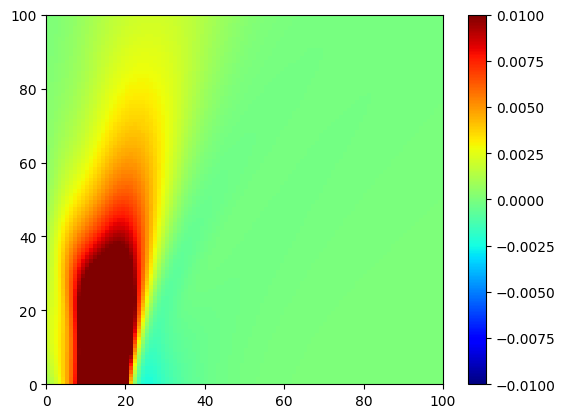

In [70]:
f2 = f2t.detach().cpu().numpy().reshape(Nu, Mu).T

plt.pcolor(f2, cmap='jet', vmin=-0.01, vmax=0.01)
plt.colorbar()

In [71]:
def z_momentum_eq(a, v, T, p, lamT):
  eps = 1e-6
  r = u_grid[:, 0]

  mu = Pr_t/Cp*lamT*lam0*lambda_mol/mu_mol + 1
  a = a * a0
  p = p * p_0
  u = a * r

  #rho = torch.ones_like(T) # in equation
  rho = (T0 + 273.15) / (T * Tnorm + T0 + 273.15) # in equation

  #derivatives
  a_r = torch.autograd.grad(a, u_grid, torch.ones_like(a), create_graph=True, \
                    retain_graph=True)[0][:, 0]
  a_z = torch.autograd.grad(a, u_grid, torch.ones_like(a), create_graph=True, \
                    retain_graph=True)[0][:, 1]/ z_0
  vr_r = r * a_r + a
  vr_z = r * a_z
  vz_r = torch.autograd.grad(v, u_grid, torch.ones_like(rho), create_graph=True, \
                          retain_graph=True)[0][:, 0]
  vz_z = torch.autograd.grad(v, u_grid, torch.ones_like(rho), create_graph=True, \
                          retain_graph=True)[0][:, 1]/ z_0
  p_z = torch.autograd.grad(p, u_grid, torch.ones_like(rho), create_graph=True, \
                          retain_graph=True)[0][:, 1]/ z_0

  # div V = 1/r*d_dr(r*VR)+d_dz(VZ)
  div_v =  r*a_r+2*a+vz_z
  #div_v[(torch.isinf(div_v)) | (torch.isnan(div_v))] = 0

  # NS equation, z-projection
  # rho * (u * d_w/d_r + w * d_w/d_z)
  n1 = rho * (u * vz_r + v * vz_z)
  #-d_p/d_z
  n2 =  -p_z
  # 1/Re0 * (d_(mu_*(-2/3 * div_v + 2*w_z))/d_z)
  n3 = 1/Re0 * 1*torch.autograd.grad(mu*(-2/3*div_v + 2*vz_z),\
                      u_grid, torch.ones_like(rho), create_graph=True, \
                          retain_graph=True)[0][:, 1]/ z_0
  # 1/Re0 * d_(mu * (w_r + u_z))/d_r
  n4 = 1/Re0 * 1*torch.autograd.grad(mu*(vz_r + vr_z),\
                      u_grid, torch.ones_like(rho), create_graph=True, \
                          retain_graph=True)[0][:, 0]
  # 1/Re0 * mu / r * (u_z+w_r)
  n5 = 1/Re0 * mu * (a_z + vz_r /(eps+r))
  #nsz_mem5[:,0,:, 0] = nsz_mem5[0,0,:, 0] * 0
  #nsz_mem5[(torch.isinf(nsz_mem5)) | (torch.isnan(nsz_mem5))] = 0

  f3 = n1 - (n2 + n3 + n4 + n5)
  return f3

In [72]:
f3t = z_momentum_eq(out[:, 0], out[:, 1],out[:, 2],out[:, 3],out[:, 4])
f3 = f3t.detach().cpu().numpy().reshape(Nu, Mu).T

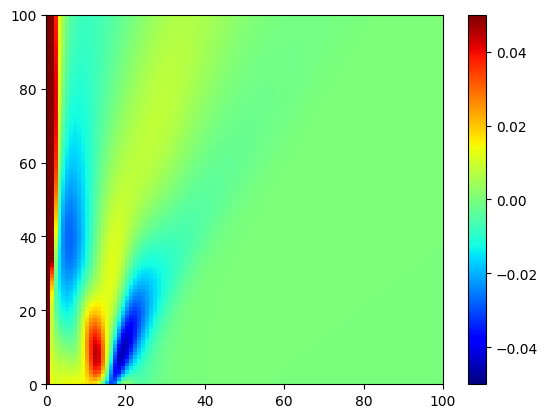

In [73]:
plt.pcolor(f3, cmap='jet', vmin=-0.05, vmax=0.05)
plt.colorbar()

In [74]:
def energy_eq(a, v, T, p, lamT):
  eps = 1e-6
  r = u_grid[:, 0]
  lamT = lamT * lam0
  a = a * a0
  p = p * p_0
  u = a * r

  #rho = torch.ones_like(T) # in equation
  rho = (T0 + 273.15) / (T * Tnorm + T0 + 273.15) # in equation

  #derivatives
  T_r = torch.autograd.grad(T, u_grid, torch.ones_like(rho), create_graph=True, \
                          retain_graph=True)[0][:, 0]
  T_z = torch.autograd.grad(T, u_grid, torch.ones_like(rho), create_graph=True, \
                          retain_graph=True)[0][:, 1]/ z_0

  #energy equation
  #rho*(u*d_T/d_r + w*d_T/d_z)
  n1 = rho * (u * T_r + v * T_z)
  #1/Pe0 * 1 / r * d_(lambda_*r*T_r)/dr
  n2 = 1/Pe0 * 1 / (eps+r)  * torch.autograd.grad(lamT*r*T_r, \
                          u_grid, torch.ones_like(rho), create_graph=True, \
                          retain_graph=True)[0][:, 0]
  #1/Pe0 * d_(lambda_*T_z)/dz
  n3 = 1/Pe0 *torch.autograd.grad(lamT*T_z, u_grid, torch.ones_like(rho), create_graph=True, \
                          retain_graph=True)[0][:, 1]/ z_0
  f4 = n1 - (n2 + n3)
  return f4

In [75]:
f4t = energy_eq(out[:, 0], out[:, 1],out[:, 2],out[:, 3],out[:, 4])
f4 = f4t.detach().cpu().numpy().reshape(Nu, Mu).T

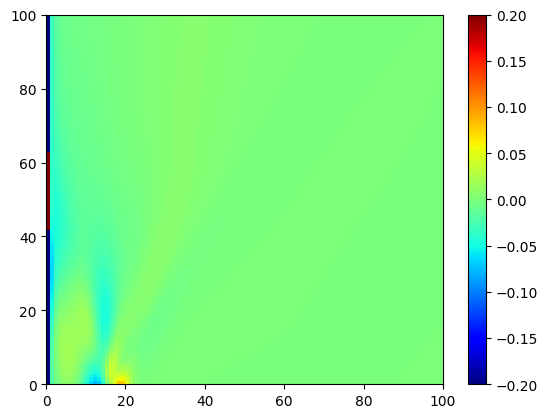

In [76]:
plt.pcolor(f4, cmap='jet', vmin=-0.2, vmax=0.2)
plt.colorbar()
plt.show()